In [1]:
%pip install scikit-learn
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import xgboost as xgb
%pip install matplotlib
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.utils.class_weight import compute_sample_weight


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install pandas numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np

In [5]:
edstays = pd.read_csv("data/mimic-iv-ed-2.2/ed/edstays.csv.gz")
triage = pd.read_csv("data/mimic-iv-ed-2.2/ed/triage.csv.gz")
vitals = pd.read_csv("data/mimic-iv-ed-2.2/ed/vitalsign.csv.gz")
medrecon = pd.read_csv("data/mimic-iv-ed-2.2/ed/medrecon.csv.gz")
pyxis = pd.read_csv("data/mimic-iv-ed-2.2/ed/pyxis.csv.gz")
diagnosis = pd.read_csv("data/mimic-iv-ed-2.2/ed/diagnosis.csv.gz")
erha = pd.read_csv("data/mimic-iv-ed-2.2/ed/complaint_to_erha_llm.csv")

In [6]:
print(edstays.columns)
print(triage.columns)
print(vitals.columns)
print(diagnosis.columns)
print(pyxis.columns)
print(medrecon.columns)
print(erha.columns)

Index(['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender',
       'race', 'arrival_transport', 'disposition'],
      dtype='str')
Index(['subject_id', 'stay_id', 'temperature', 'heartrate', 'resprate',
       'o2sat', 'sbp', 'dbp', 'pain', 'acuity', 'chiefcomplaint'],
      dtype='str')
Index(['subject_id', 'stay_id', 'charttime', 'temperature', 'heartrate',
       'resprate', 'o2sat', 'sbp', 'dbp', 'rhythm', 'pain'],
      dtype='str')
Index(['subject_id', 'stay_id', 'seq_num', 'icd_code', 'icd_version',
       'icd_title'],
      dtype='str')
Index(['subject_id', 'stay_id', 'charttime', 'med_rn', 'name', 'gsn_rn',
       'gsn'],
      dtype='str')
Index(['subject_id', 'stay_id', 'charttime', 'name', 'gsn', 'ndc', 'etc_rn',
       'etccode', 'etcdescription'],
      dtype='str')
Index(['complaint', 'freq', 'erha_codes', 'erha_names', 'confidence',
       'parse_error', 'reviewed'],
      dtype='str')


In [7]:
ed_triage = edstays.merge(triage, on="stay_id", how="left")

In [8]:
vitals_first = (vitals.sort_values("charttime").groupby("stay_id").first().reset_index())

In [9]:
ed_triage = ed_triage.merge(
    vitals_first[["stay_id", "charttime", "rhythm"]],
    on="stay_id",
    how="left"
)

In [10]:
ed_triage["Chief_Complaints"] = (ed_triage["chiefcomplaint"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
erha["Chief_Complaints"] = (erha["complaint"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
triage["Chief_Complaints"] = (triage["chiefcomplaint"].str.strip().str.lower().str.replace(r"\s+", " ", regex=True))
print(erha.columns)
print(ed_triage.columns)

Index(['complaint', 'freq', 'erha_codes', 'erha_names', 'confidence',
       'parse_error', 'reviewed', 'Chief_Complaints'],
      dtype='str')
Index(['subject_id_x', 'hadm_id', 'stay_id', 'intime', 'outtime', 'gender',
       'race', 'arrival_transport', 'disposition', 'subject_id_y',
       'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain',
       'acuity', 'chiefcomplaint', 'charttime', 'rhythm', 'Chief_Complaints'],
      dtype='str')


In [11]:
print(ed_triage.shape)
print(erha.shape)
ed_triage = ed_triage.merge(
    erha[["Chief_Complaints", "erha_codes", "erha_names"]],
    on="Chief_Complaints",
    how="left"
)

(425087, 22)
(57928, 8)


In [12]:
ed_triage.tail(2)

,subject_id_x,hadm_id,stay_id,intime,outtime,gender,race,arrival_transport,disposition,subject_id_y,...,sbp,dbp,pain,acuity,chiefcomplaint,charttime,rhythm,Chief_Complaints,erha_codes,erha_names
425085,19999914,NaN,32002659,2158-12-24 11:41:00,2158-12-24 11:56:00,F,UNKNOWN,UNKNOWN,ELOPED,19999914,...,93.0,55.0,0,2.0,"Altered mental status, Substance use",2158-12-24 11:43:00,NaN,"altered mental status, substance use",ERHA16;ERHA53,의식장애;중독
425086,19999987,23865745.0,34731548,2145-11-02 19:28:00,2145-11-02 22:59:00,F,UNKNOWN,AMBULANCE,ADMITTED,19999987,...,NaN,NaN,NaN,NaN,HEAD BLEED,2145-11-02 19:40:00,Sinus Tachycardia,head bleed,ERHA36,그밖의출혈


In [13]:
ed_triage.loc[[0,1,2,3,4],('temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain')]

,temperature,heartrate,resprate,o2sat,sbp,dbp,pain
0,98.4,70.0,16.0,97.0,106.0,63.0,0
1,98.9,88.0,18.0,97.0,116.0,88.0,10
2,99.4,105.0,18.0,96.0,106.0,57.0,10
3,97.8,87.0,14.0,97.0,71.0,43.0,7
4,98.7,77.0,16.0,98.0,96.0,50.0,13


In [14]:
print(ed_triage["Chief_Complaints"].nunique())
print(erha["complaint"].nunique())

57927
57927


In [15]:
ed_triage.isnull().sum().sort_values(ascending=False)

rhythm               397033
hadm_id              222071
temperature           23415
o2sat                 20596
resprate              20353
dbp                   19091
sbp                   18291
heartrate             17090
charttime             16941
pain                  12933
acuity                 6987
chiefcomplaint           23
Chief_Complaints         23
intime                    0
subject_id_x              0
stay_id                   0
arrival_transport         0
race                      0
gender                    0
outtime                   0
subject_id_y              0
disposition               0
erha_codes                0
erha_names                0
dtype: int64

In [16]:
ed_triage.dtypes

subject_id_x           int64
hadm_id              float64
stay_id                int64
intime                   str
outtime                  str
gender                   str
race                     str
arrival_transport        str
disposition              str
subject_id_y           int64
temperature          float64
heartrate            float64
resprate             float64
o2sat                float64
sbp                  float64
dbp                  float64
pain                     str
acuity               float64
chiefcomplaint           str
charttime                str
rhythm                   str
Chief_Complaints         str
erha_codes               str
erha_names               str
dtype: object

In [17]:
ed_triage['pain'] = pd.to_numeric(ed_triage['pain'],errors='coerce')
ed_triage['rhythm'] = pd.to_numeric(ed_triage['rhythm'],errors='coerce')

In [18]:
ed_triage["acuity_group"] = np.nan

#ed_triage.loc[ed_triage["acuity"] == 1, "acuity_group"] = 0
#ed_triage.loc[ed_triage["acuity"] == 2, "acuity_group"] = 1
#ed_triage.loc[ed_triage["acuity"] == 3, "acuity_group"] = 2
#ed_triage.loc[ed_triage["acuity"] == 4, "acuity_group"] = 3
#ed_triage.loc[ed_triage["acuity"] == 5, "acuity_group"] = 4

ed_triage.loc[ed_triage["acuity"] < 3, "acuity_group"] = 0
ed_triage.loc[ed_triage["acuity"] == 3, "acuity_group"] = 1
ed_triage.loc[ed_triage["acuity"] > 3, "acuity_group"] = 2
ed_triage = ed_triage.dropna(subset=["acuity_group"])

In [19]:
ed_triage["stay_id"].nunique()

418100

In [20]:
ed_triage["acuity"].value_counts(dropna=False)

acuity
3.0    225066
2.0    139411
4.0     28504
1.0     24019
5.0      1100
Name: count, dtype: int64

In [21]:
def bad_high(type, limit,name):
    ed_triage[name] = (ed_triage[type].gt(limit) ).fillna(False).astype(int)
    
def bad_low(type, limit,name):
    ed_triage[name] = (ed_triage[type].lt(limit) ).fillna(False).astype(int)

    
def missing(type,name):
    ed_triage[name] = ed_triage[type].isna().astype(int)
    
def normal(type, hi_limit,low_limit,name):
    ed_triage[name] =  ((ed_triage[type].gt(low_limit) ) | (ed_triage[type].lt(hi_limit) )).fillna(False).astype(int)


def extremes(type, hi_limit,low_limit,name):
    ed_triage[name] =  ((ed_triage[type].lt(low_limit) ) | (ed_triage[type].gt(hi_limit) )).fillna(False).astype(int)


In [22]:

normal('temperature',96,100,'normalTemp')
normal('heartrate',59,101,'normalheart')
normal('o2sat',94,101,'normalSpO2')
normal('resprate',11,21,'normalbreathe')

bad_low('o2sat',95,'low_Spo2')

extremes('temperature',95,104,'Bad_temp')
extremes('heartrate',40,120,'Bad_temp')
extremes('resprate',12,25,'normalbreathe')

missing('temperature','No_temp')
missing('heartrate','No_heart')
missing('resprate','No_breath')
missing('o2sat','No_Spo2')
missing('sbp','No_sbp')
missing('dbp','No_dbp')
missing('pain','No_pain')

ed_triage.columns.tolist()

['subject_id_x',
 'hadm_id',
 'stay_id',
 'intime',
 'outtime',
 'gender',
 'race',
 'arrival_transport',
 'disposition',
 'subject_id_y',
 'temperature',
 'heartrate',
 'resprate',
 'o2sat',
 'sbp',
 'dbp',
 'pain',
 'acuity',
 'chiefcomplaint',
 'charttime',
 'rhythm',
 'Chief_Complaints',
 'erha_codes',
 'erha_names',
 'acuity_group',
 'normalTemp',
 'normalheart',
 'normalSpO2',
 'normalbreathe',
 'low_Spo2',
 'Bad_temp',
 'No_temp',
 'No_heart',
 'No_breath',
 'No_Spo2',
 'No_sbp',
 'No_dbp',
 'No_pain']

In [ ]:
numeric_features = [
    'temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain', 'normalTemp',
 'normalheart',
 'normalSpO2',
 'normalbreathe',
 'low_Spo2',
 'Bad_temp',
 'No_temp',
 'No_heart'
 'No_breath',
  'No_Spo2',
  'No_sbp',
  'No_dbp',
  'No_pain']
categorical_features = ['arrival_transport','race', 'gender','erha_names','erha_codes']
feature =numeric_features+ categorical_features  + ["Chief_Complaints"]
x = ed_triage[feature]
y = ed_triage['acuity_group']

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [25]:
print(y_train.value_counts())

acuity_group
1.0    180053
0.0    130744
2.0     23683
Name: count, dtype: int64


In [26]:
x_train = x_train.copy()
x_test = x_test.copy()
class_weights = {
    0: 1.4,
    1: 1,
    2: 2.4
}   
train_sample_weights = compute_sample_weight(class_weight=class_weights, y=y_train)

x_train["Chief_Complaints"] = (
    x_train["Chief_Complaints"]
    .fillna("")
    .astype(str)
)

x_test["Chief_Complaints"] = (
    x_test["Chief_Complaints"]
    .fillna("")
    .astype(str)
)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('str', categorical_pipeline, categorical_features),
     ('text', TfidfVectorizer(max_features=500,ngram_range=(1, 2),stop_words="english"), "Chief_Complaints")
])

In [27]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
    ))
])


model.fit(x_train, y_train,classifier__sample_weight=train_sample_weights)

predictions = model.predict(x_test)

In [28]:
accuracy = accuracy_score(y_test, predictions)
precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

recall = recall_score(
    y_test,
    predictions,
    average="weighted"
)

f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Accuracy: 0.7055847883281512
Precision: 0.709045664576161
Recall: 0.7055847883281512
F1: 0.7060225617783373


In [29]:
print(classification_report(
    y_test,
    predictions,
    target_names=["high","mid","low"]
))

              precision    recall  f1-score   support

        high       0.69      0.76      0.73     32686
         mid       0.75      0.69      0.72     45013
         low       0.46      0.49      0.48      5921

    accuracy                           0.71     83620
   macro avg       0.64      0.65      0.64     83620
weighted avg       0.71      0.71      0.71     83620



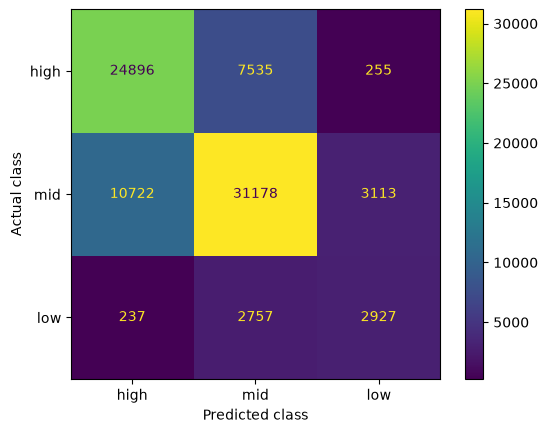

In [30]:
cm = confusion_matrix(y_test,predictions)
cfd = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["high","mid","low"]
)
cfd.plot()
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.show()